# 反応器形式の選択 — なぜ Catofin 浅床・多基並列か

本ノートは反応器**形式**の選択を、同一の反応器入口で3候補を実走比較して説明する。

- **軸流深床**(出発点): 0.5 bar 低圧で Ergun 圧損が破綻(`reactor_pressure_drop_and_geometry.ipynb`)。
- **radial 多段**(径方向流断熱床を直列+段間再加熱, UOP Oleflex 型): 圧損は解けるが、段数を増やすと
  転化率↑の代わりに**選択率(=総収率)↓**、かつ直列の内部品/分配板/再生温度分布の不確かさが大きい。
- **Catofin 浅床・多基並列**(現採用, Lummus Catofin 型): 浅床で圧損、並列基数で流速、**HGM 等価熱補償**で
  床温を維持。**低per-pass転化でも高選択率(=高総収率)**を保ち、直列段が不要で単純。

> 鍵: **総収率 ≈ 単通選択率**(リサイクルが未反応プロパンを消尽)。だから「単通転化率を上げて選択率を
> 犠牲にする」より「**選択率を保ち、不足分はリサイクル**」が総収率で有利。Catofin はこれに合致する。
>
> 反応器は純 Python (scipy ODE)。HYSYS 不要。数値は BO best (trial #227) の反応器入口。


In [1]:
import os, sys, math, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from units.reactors.swing import (DesignVars as AxialDesign, FeedStream, FixedParams,
                                  simulate_swing_reactor_system)
from units.reactors.radial_flow import RadialDesignVars, simulate_radial_multibed_reactor_system
from units.reactors.catofin import CatofinDesignVars, simulate_catofin_reactor_system

# BO best #227 (catofin) の反応器入口: C3H8 70% + C3H6 リサイクル 30% (H2/C2 は除去済)
FEED = FeedStream(F_in={'A': 3811.6, 'B': 1635.7, 'C': 0., 'D': 0., 'E': 0., 'F': 0.},
                  T_feed=305.03, P_in=50000.)
def metrics(r):
    e, p = r.equipment, r.performance
    return dict(X=p.Conversion, S=p.Selectivity, dP=min(e.dP_over_P_actual*100, 999),
                Ntot=e.N_reactors_total, cat=e.Catalyst_Weight_Total/1000,
                pen=e.penalty_reason or 'OK')
print('reactor inlet:', sum(FEED.F_in.values()), 'kmol/h  (C3H6 分率 30%)  P=0.5bar')

reactor inlet: 5447.3 kmol/h  (C3H6 分率 30%)  P=0.5bar


## §1+§2. 出発点 — 単段の軸流深床は 0.5 bar で圧損破綻

PDH は 0.5 bar 低圧運転(平衡転化率のため不可欠)。現実的な 3mm 触媒では、軸流の**深い**充填層は
Ergun 圧損が入口圧の数十%〜全損に達し**成立しない**(詳細は圧損ノート)。まずこれを確認する。


In [2]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    r_ax = simulate_swing_reactor_system(AxialDesign(T_in=931.13, z_cat=20., t_cyc=14., D=10.),
                                         FEED, FixedParams(d_p_m=0.003))
m = metrics(r_ax)
print(f'軸流深床 z=20m d_p=3mm: dP/P={m["dP"]:.0f}%  penalty={m["pen"]}  → 成立しない')
print('→ 圧力(=平衡)で妥協できないので、反応器の幾何で解く。候補は radial 多段 と Catofin 浅床多基。')

軸流深床 z=20m d_p=3mm: dP/P=100%  penalty=dP_excess  → 成立しない
→ 圧力(=平衡)で妥協できないので、反応器の幾何で解く。候補は radial 多段 と Catofin 浅床多基。


## §3. 2つの解の比較 — radial 多段 vs Catofin 浅床多基(同一入口)

- **radial 多段**: 径方向流断熱床を $N$ 段直列、段間で反応温度へ再加熱(平衡リセット)。段数で累積転化率↑。
- **Catofin**: 浅床を $N_{online}$ 基**並列**、HGM 等価熱補償で床温維持。床体積で転化率↑(`reactor_conversion_ceiling.ipynb`)。


        form    X    S  dP  Ntot    cat pen
   radial 1段 23.0 75.7 1.1     6  604.4  OK
   radial 2段 41.3 72.2 2.4    12 1208.7  OK
   radial 3段 54.7 70.1 3.8    18 1813.1  OK
   radial 4段 64.7 68.5 5.3    24 2417.5  OK
Catofin #227 37.8 82.6 3.5    96 1487.1  OK

観察: radial は段数↑で X↑ だが S↓ (高転化→クラッキング)。Catofin は X=38% で S=82.6% と高い。


C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30232\810006920.py:31: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30232\810006920.py:31: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yuish\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


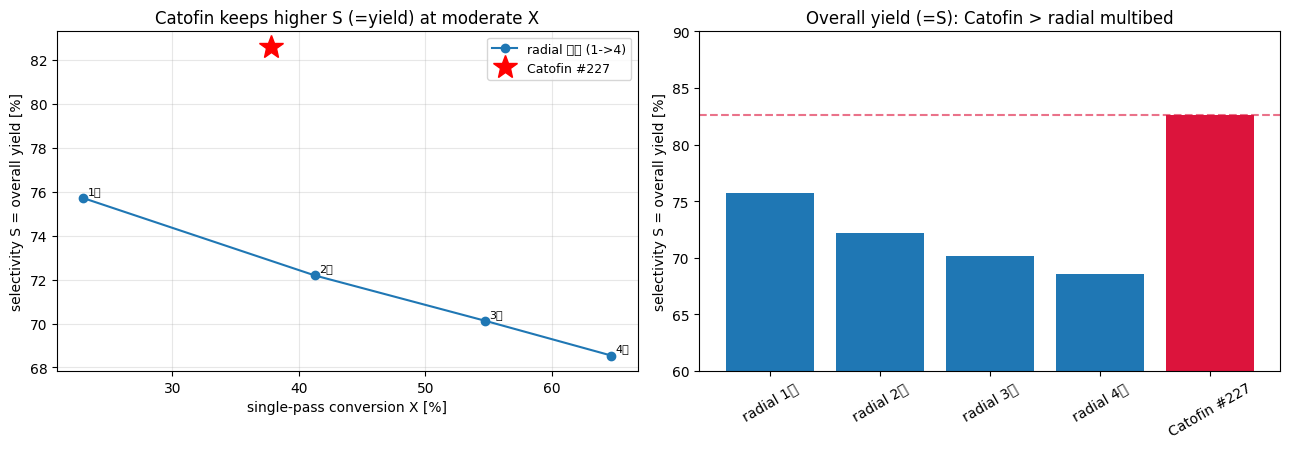

In [3]:
rows = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for nbed in (1, 2, 3, 4):
        r = simulate_radial_multibed_reactor_system(
            RadialDesignVars(T_in=939., t_cyc=17., D_inner=9., bed_thickness=0.5, H=30.),
            FEED, FixedParams(), n_beds=nbed)
        m = metrics(r); rows.append(dict(form=f'radial {nbed}段', **m))
    rc = simulate_catofin_reactor_system(
        CatofinDesignVars(T_in=931.13, t_cyc=13.99, D=6.771, L_bed=0.956, N_online=24, d_p=0.003156), FEED)
    rows.append(dict(form='Catofin #227', **metrics(rc)))
df = pd.DataFrame(rows)
print(df[['form','X','S','dP','Ntot','cat','pen']].round(1).to_string(index=False))
print()
print('観察: radial は段数↑で X↑ だが S↓ (高転化→クラッキング)。Catofin は X=38% で S=82.6% と高い。')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
rad = df[df.form.str.startswith('radial')]
ax[0].plot(rad.X, rad.S, 'o-', color='C0', label='radial 多段 (1->4)')
for _, rw in rad.iterrows():
    ax[0].annotate(rw.form.replace('radial ',''), (rw.X, rw.S), fontsize=8, xytext=(3,3), textcoords='offset points')
cat = df[df.form=='Catofin #227'].iloc[0]
ax[0].plot(cat.X, cat.S, 'r*', ms=18, label='Catofin #227')
ax[0].set_xlabel('single-pass conversion X [%]'); ax[0].set_ylabel('selectivity S = overall yield [%]')
ax[0].set_title('Catofin keeps higher S (=yield) at moderate X'); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

ax[1].bar(df.form, df.S, color=['C0','C0','C0','C0','crimson'])
ax[1].set_ylabel('selectivity S = overall yield [%]'); ax[1].set_ylim(60, 90)
ax[1].axhline(cat.S, ls='--', color='crimson', alpha=0.6)
ax[1].set_title('Overall yield (=S): Catofin > radial multibed'); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## §4. なぜ Catofin か

**総収率 ≈ 単通選択率**(未反応プロパンはリサイクルで消尽 → 炭素損失はクラッキング=選択率で決まる)。
したがって設計目標は「単通転化率を最大化」ではなく「**選択率(=総収率)を保ちつつ系が成立する転化率を確保**」。

| 観点 | radial 多段 | **Catofin 浅床多基(採用)** |
|---|---|---|
| 圧損 (0.5bar) | 解ける(薄い環状床) | 解ける(浅床+多基) |
| 単通転化率 | 段数で高くできる(3段 ~55%) | HGM+床体積で ~38% |
| **選択率(=総収率)** | 高転化で**低下(3段 ~70%)** | **高く保てる(~82.6%)** ← 総収率で有利 |
| 床温維持 | 段間**再加熱炉**(直列に必要) | **HGM 等価熱補償**(再加熱炉不要) |
| 機構の不確かさ | 直列の内部品/分配板/再生温度分布が複雑 | 並列スイング、相対的に単純 |

- **Catofin は低per-pass転化(~38%)でも高選択率(~82.6%)を保つ** → 総収率で radial 多段(高転化・低選択率)に勝る。
  不足分の転化はリサイクルが担う。
- 段間再加熱の直列トレインが不要(HGM が床温維持)。
- **radial は撤去**: 内部品/分配板/再生時の温度分布の不確かさが大きく、本設計のモデル精度では正当化しにくい。


## §5. Catofin の設計レバー — 直列「段数」に代わるもの

Catofin に直列段は無い。主レバーは **$N_{online}$(並列基数)** と **$L_{bed}$(浅床厚)**:
- $N_{online}$: 大流量を分割 → 1基流速↓ → **圧損↓ かつ 滞留時間↑で転化率↑**(圧損と転化の両方を動かす主レバー)。
- $L_{bed}$: 床体積 → 転化率(HGM が温度を保つので平衡頭打ちなし)。


N_online 掃引 (浅床多基の「基数」= 直列段数の代替):
  N_online= 6: X= 0.0%  S= 0.0%  dP/P=17.9%  N_total=  0  dP_excess


  N_online= 8: X= 0.0%  S= 0.0%  dP/P=11.9%  N_total=  0  dP_excess


  N_online=10: X=21.6%  S=82.6%  dP/P= 8.8%  N_total= 40  OK


  N_online=14: X=27.2%  S=82.8%  dP/P= 5.7%  N_total= 56  OK


  N_online=18: X=31.9%  S=82.8%  dP/P= 4.2%  N_total= 72  OK


  N_online=24: X=37.8%  S=82.6%  dP/P= 3.5%  N_total= 96  OK


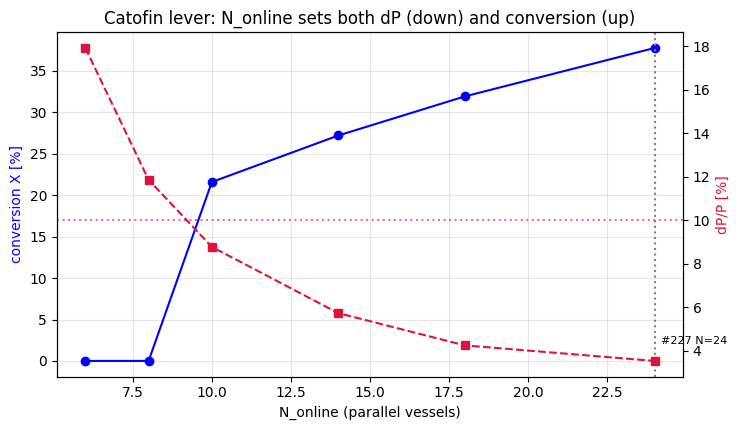


→ N_online が小さいと圧損超過(N=6 で失敗)。基数を増やすと圧損が下がり転化率も上がる。
  #227 は N_online=24 で ΔP 余裕(3.5%)と必要転化率(38%, S=82.6%)を両立。


In [4]:
def run_cat(**kw):
    d = dict(T_in=931.13, t_cyc=13.99, D=6.771, L_bed=0.956, N_online=24, d_p=0.003156); d.update(kw)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return metrics(simulate_catofin_reactor_system(CatofinDesignVars(**d), FEED))

print('N_online 掃引 (浅床多基の「基数」= 直列段数の代替):')
Ns = [6, 8, 10, 14, 18, 24]; Xn, dPn = [], []
for n in Ns:
    m = run_cat(N_online=n); Xn.append(m['X']); dPn.append(m['dP'])
    print(f'  N_online={n:>2}: X={m["X"]:4.1f}%  S={m["S"]:4.1f}%  dP/P={m["dP"]:4.1f}%  N_total={m["Ntot"]:>3}  {m["pen"]}')

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(Ns, Xn, 'o-', color='blue', label='conversion X [%]')
ax2 = ax.twinx(); ax2.plot(Ns, dPn, 's--', color='crimson', label='dP/P [%]')
ax2.axhline(10, ls=':', color='crimson', alpha=0.6); ax.axvline(24, ls=':', color='gray')
ax.text(24.2, min(Xn)+2, '#227 N=24', fontsize=8)
ax.set_xlabel('N_online (parallel vessels)'); ax.set_ylabel('conversion X [%]', color='blue')
ax2.set_ylabel('dP/P [%]', color='crimson')
ax.set_title('Catofin lever: N_online sets both dP (down) and conversion (up)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('\n→ N_online が小さいと圧損超過(N=6 で失敗)。基数を増やすと圧損が下がり転化率も上がる。')
print('  #227 は N_online=24 で ΔP 余裕(3.5%)と必要転化率(38%, S=82.6%)を両立。')

## §6. 結論

| 形式 | 圧損(0.5bar) | 単通X | 選択率(=総収率) | 機構 | 判定 |
|---|---|---|---|---|---|
| 軸流深床 | **破綻** | — | — | 単純 | 不成立 |
| radial 多段(3段) | OK | 高(~55%) | **低(~70%)** | 直列+段間再加熱+内部品(不確か) | 撤去 |
| **Catofin 浅床多基** | **OK** | 中(~38%) | **高(~82.6%)** | 並列スイング+HGM(再加熱炉不要) | **採用** |

- **総収率 ≈ 選択率**なので、Catofin の「低per-pass転化・高選択率」は radial 多段の「高転化・低選択率」より
  総収率で有利。不足転化はリサイクルが担う。
- Catofin は段間再加熱の直列トレインが不要(HGM が床温維持)で、内部品/分配の不確かさも radial より小さい。
- 設計レバーは直列「段数」でなく **$N_{online}$(並列基数, 圧損+転化の主レバー)** と $L_{bed}$(転化)。
  #227 は $N_{online}=24$ で圧損余裕と必要転化率を両立。 **→ Catofin 浅床・多基並列を採用**。

> 数値は #227 設計点。radial の段数比較は撤去理由の定量化として残す(履歴)。HGM 再生動特性はスコープ外。
